# DS 4320 Project 1 — Solution Pipeline
**New User Recommendation Model for Netflix**

**Author:** Rebecca Vanni

**NetID:** ecn2wh


### Setup and Packages

In [9]:
# Install required packages if not already present
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import logging
import os
from sklearn.metrics.pairwise import cosine_similarity

#Creating Pipeline
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info('Pipeline notebook started')
print('Setup complete.')

Setup complete.


### Load Raw Data into DuckDB

Creating the four tables:

- movies: cleaned movie metadata with year extracted
- ratings_agg: per-movie average rating and count (min 50 ratings threshold)
- genome_tags: tag label lookup table
- genome_scores: tag relevance scores per movie (filtered to valid movies only)

In [11]:
# Paths were the raw csv's will be in colab
RAW_DIR = '/content'
DB_PATH = '/content/movielens.db'
#setting the thresholds for movies with 50 ratings or above
MIN_RATINGS = 50

#connecting the DuckDB path
try:
    con = duckdb.connect(DB_PATH)
    logging.info('Connected to DuckDB at %s', DB_PATH)
    #dropping the table which already exist
    for t in ['genome_scores', 'genome_tags', 'ratings_agg', 'movies']:
        con.execute(f'DROP TABLE IF EXISTS {t}')

    # Creating table 1 (movies)
    # Extract release year from title using regex; drop rows with no genre
    con.execute(f"""
        CREATE TABLE movies AS
        SELECT
            CAST(movieId AS INTEGER) AS movieId,
            title,
            genres,
            TRY_CAST(regexp_extract(title, '\\((\\d{{4}})\\)$', 1) AS INTEGER) AS year
        FROM read_csv_auto('{RAW_DIR}/movies.csv')
        WHERE genres != '(no genres listed)'
    """)
    logging.info('movies created')

    #creating table 2 (ratings agg)
    # Aggregate 25M ratings into per-movie avg + count and apply min filter
    con.execute(f"""
        CREATE TABLE ratings_agg AS
        SELECT
            CAST(movieId AS INTEGER) AS movieId,
            ROUND(AVG(rating), 4)    AS avg_rating,
            COUNT(*)                 AS rating_count
        FROM read_csv_auto('{RAW_DIR}/ratings.csv', ignore_errors=true)
        GROUP BY movieId
        HAVING COUNT(*) >= {MIN_RATINGS}
    """)
    logging.info('ratings_agg created')

    #applying threhold to only get movies with enough ratings
    con.execute('DELETE FROM movies WHERE movieId NOT IN (SELECT movieId FROM ratings_agg)')

    #Table three: genome tags
    con.execute(f"""
        CREATE TABLE genome_tags AS
        SELECT
            CAST(tagId AS INTEGER) AS tagId,
            tag
        FROM read_csv_auto('{RAW_DIR}/genome-tags.csv')
    """)
    logging.info('genome_tags created')

    # table four: genomes scores
    # filter to only movies that survived the threshold and cleaning
    con.execute(f"""
        CREATE TABLE genome_scores AS
        SELECT
            CAST(gs.movieId   AS INTEGER) AS movieId,
            CAST(gs.tagId     AS INTEGER) AS tagId,
            CAST(gs.relevance AS DOUBLE)  AS relevance
        FROM read_csv_auto('{RAW_DIR}/genome-scores.csv') gs
        WHERE gs.movieId IN (SELECT movieId FROM movies)
    """)
    logging.info('genome_scores created')

except Exception as e:
    logging.error('Data load failed: %s', str(e))
    raise

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- Table Row Counts ---
  movies              :      9,318 rows
  ratings_agg         :      9,337 rows
  genome_tags         :      1,128 rows
  genome_scores       :  6,514,200 rows


### Query

The three queries I will do to extract the data for the recommender are:

- Genre mapping, explodes the pipe-delimited genre string into one row per genre per movie so I can match a user's survey responses.
- Tag - genome pivot, pulls the full relevance matrix for candidate movies. This is the content feature space for cosine similarity.
- Popularity scores, computes a normalized popularity score combining avg_rating and log(rating_count) to break ties between similarly relevant movies.

In [12]:
# Genre mapping - explodes the movie id.
# filter movies which are candiates for recommending by users liked genres
try:
    genre_df = con.execute("""
        SELECT
            m.movieId,
            m.title,
            m.year,
            TRIM(genre_item) AS genre
        FROM movies m,
             UNNEST(string_split(m.genres, '|')) AS t(genre_item)
        WHERE TRIM(genre_item) != 'IMAX'
        ORDER BY m.movieId
    """).df()

    logging.info('genre_df: %d rows, %d unique movies', len(genre_df), genre_df['movieId'].nunique())
    print(f'genre_df: {len(genre_df):,} rows | {genre_df["movieId"].nunique():,} unique movies')
    print(f'Genres available: {sorted(genre_df["genre"].unique())}')
    genre_df.head()

except Exception as e:
    logging.error('Genre query failed: %s', str(e))
    raise

genre_df: 21,033 rows | 9,318 unique movies
Genres available: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [13]:
# Pull genome scores and join tags
# Movie x tag matrix for cosine similarity
try:
    genome_df = con.execute("""
        SELECT
            gs.movieId,
            gt.tag,
            gs.relevance
        FROM genome_scores gs
        JOIN genome_tags gt ON gs.tagId = gt.tagId
        ORDER BY gs.movieId, gt.tag
    """).df()

    logging.info('genome_df: %d rows', len(genome_df))
    print(f'genome_df: {len(genome_df):,} rows')
    genome_df.head()

except Exception as e:
    logging.error('Genome query failed: %s', str(e))
    raise

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

genome_df: 6,514,200 rows


In [14]:
# Compute popularity score
# Combines avg_rating and log-scaled rating_count into a single 0-1 normalized score
# need to adjust scores to make sure only popular movies aren't being considered
# normalized to include the more niche movies
try:
    popularity_df = con.execute("""
        WITH scored AS (
            SELECT
                r.movieId,
                m.title,
                r.avg_rating,
                r.rating_count,
                -- weighted score: 60% average rating (normalized 0-5) + 40% log popularity
                (0.6 * (r.avg_rating / 5.0)) +
                (0.4 * (LN(r.rating_count) / LN((SELECT MAX(rating_count) FROM ratings_agg))))
                    AS popularity_score
            FROM ratings_agg r
            JOIN movies m ON r.movieId = m.movieId
        )
        SELECT
            movieId,
            title,
            avg_rating,
            rating_count,
            ROUND(popularity_score, 4) AS popularity_score
        FROM scored
        ORDER BY popularity_score DESC
    """).df()

    logging.info('popularity_df: %d rows', len(popularity_df))
    print(f'popularity_df: {len(popularity_df):,} movies')
    popularity_df.head(10)

except Exception as e:
    logging.error('Popularity query failed: %s', str(e))
    raise

popularity_df: 9,318 movies


### Creating model - cold-start problem

**Model Choice: Content-Based Filtering via Cosine Similarity on the Tag Genome**

Steps for the solution:
1. The user answers a one-question genre survey - goal of having 1-3 genres to filter between
2. Identify genre-relevant tags from the genome - tags with genre in  
3. Build a user profile vector (the mean tag-genome vector of the top-rated movies in those genres)
4. Compute cosine similarity between the user profile and every candidate movie's genome vector
5. Rerank by a weighted combination of cosine similarity (70%) and popularity score (30%)
6. The top 5 results are returned as the recommendation list

In [15]:
# pivot the genome into a movie x tag matrix
# Core feature matrix for cosine similarity
try:
    genome_matrix = genome_df.pivot(index='movieId', columns='tag', values='relevance').fillna(0)
    logging.info('genome_matrix shape: %s', genome_matrix.shape)
    print(f'Genome matrix shape: {genome_matrix.shape}  (movies × tags)')
    genome_matrix.iloc[:3, :5]

except Exception as e:
    logging.error('Pivot failed: %s', str(e))
    raise

Genome matrix shape: (5775, 1128)  (movies × tags)


In [16]:
#Cold-start recommender using cosine similarity on the tag genome.
def recommend_movies(user_genres, genre_df, genome_matrix, popularity_df,
                     top_n=5, sim_weight=0.7, pop_weight=0.3):

    try:
        #find candidate movies that match at least one of the user's genres
        candidates = genre_df[genre_df['genre'].isin(user_genres)]['movieId'].unique()
        logging.info('Candidates for genres %s: %d movies', user_genres, len(candidates))

        if len(candidates) == 0:
            raise ValueError(f'No movies found for genres: {user_genres}')

        # Build the user profile vector
        # popular movies as the profile seed ensures build a vector
        pop_candidates = (
            popularity_df[popularity_df['movieId'].isin(candidates)]
            # Take the top-50 most popular genre-matching movies and average their genome vectors
            .nlargest(50, 'popularity_score')['movieId']
            .values
        )

        # filter to only those that have genome data
        seed_ids = [mid for mid in pop_candidates if mid in genome_matrix.index]
        if len(seed_ids) == 0:
            raise ValueError('No seed movies with genome data found.')

        user_profile = genome_matrix.loc[seed_ids].mean(axis=0).values.reshape(1, -1)
        logging.info('User profile built from %d seed movies', len(seed_ids))

        #filter genome_matrix to candidate movies only
        candidate_ids = [mid for mid in candidates if mid in genome_matrix.index]
        candidate_matrix = genome_matrix.loc[candidate_ids]

        # compute cosine similarity between user profile and all candidates
        sim_scores = cosine_similarity(user_profile, candidate_matrix.values)[0]
        sim_series = pd.Series(sim_scores, index=candidate_ids, name='cosine_sim')

        # normalize similarity scores to 0-1
        sim_min, sim_max = sim_series.min(), sim_series.max()
        sim_norm = (sim_series - sim_min) / (sim_max - sim_min + 1e-9)

        # merge with popularity scores
        pop_lookup = popularity_df.set_index('movieId')['popularity_score']
        pop_norm = pop_lookup.reindex(candidate_ids).fillna(0)
        # normalize popularity too
        pop_norm = (pop_norm - pop_norm.min()) / (pop_norm.max() - pop_norm.min() + 1e-9)

        # final weighted score
        final_score = (sim_weight * sim_norm) + (pop_weight * pop_norm)

        # assemble results DF
        results = pd.DataFrame({
            'movieId'      : candidate_ids,
            'cosine_sim'   : sim_series.values,
            'pop_score'    : pop_lookup.reindex(candidate_ids).values,
            'final_score'  : final_score.values
        }).set_index('movieId')

        # merge in title and rating info
        results = results.join(popularity_df.set_index('movieId')[['title', 'avg_rating', 'rating_count']])
        results = results.sort_values('final_score', ascending=False)

        # memove seed movies from recommendations (don't recommend profile-builders)
        results = results[~results.index.isin(seed_ids)]

        logging.info('Recommendation complete. Returning top %d.', top_n)
        return results.head(top_n).reset_index()

    except Exception as e:
        logging.error('Recommendation failed: %s', str(e))
        raise
DataFrame with top_n recommended movies and their scores

recommend_movies() function defined.


### Top-5 Recommendations (EXP)

simulating with fake user

In [17]:
# need to create a simulation of the new user survey
# this would come up as a ui when the user signs into the platform
USER_GENRES = ['Action', 'Sci-Fi']

recommendations = recommend_movies(
    user_genres    = USER_GENRES,
    genre_df       = genre_df,
    genome_matrix  = genome_matrix,
    popularity_df  = popularity_df,
    top_n          = 5,
    sim_weight     = 0.7,
    pop_weight     = 0.3
)

# creating clean table to show results
display_cols = ['title', 'avg_rating', 'rating_count', 'cosine_sim', 'final_score']
print('=== Top-5 Recommended Movies ===')
recommendations[display_cols].style.format({
    'avg_rating'   : '{:.2f}',
    'rating_count' : '{:,.0f}',
    'cosine_sim'   : '{:.4f}',
    'final_score'  : '{:.4f}'
})

New user genre preferences: ['Action', 'Sci-Fi']
Generating top-5 recommendations...

=== Top-5 Recommended Movies ===


,title,avg_rating,rating_count,cosine_sim,final_score
0,Run Lola Run (Lola rennt) (1998),3.97,"6,975",0.8948,0.9239
1,Butch Cassidy and the Sundance Kid (1969),4.05,"5,701",0.8929,0.9212
2,Jaws (1975),3.79,"9,029",0.8856,0.9012
3,Close Encounters of the Third Kind (1977),3.78,"5,581",0.8864,0.8931
4,Once Upon a Time in the West (C'era una volta il West) (1968),4.12,"2,081",0.8824,0.8868


### Visualization

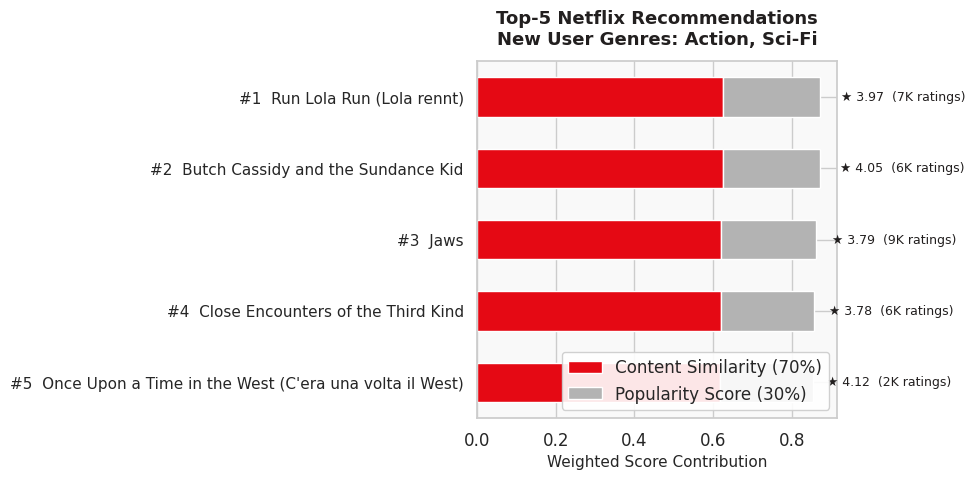

Chart saved to recommendation_scores.png


In [18]:
# Score breakdown bar chart
# Shows how much each component (content similarity vs popularity) contributes
sns.set_theme(style='whitegrid', font_scale=1.1)
BRAND_RED   = '#E50914'   # Netflix red
BRAND_DARK  = '#221F1F'   # Netflix dark
BRAND_GRAY  = '#B3B3B3'

fig, ax = plt.subplots(figsize=(10, 5))
titles     = recommendations['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
sim_vals   = recommendations['cosine_sim']
pop_vals   = recommendations['pop_score']
y_pos      = range(len(titles))

# Stacked horizontal bars (similarity component + popularity component)
bars1 = ax.barh(y_pos, sim_vals * 0.7, color=BRAND_RED,  label='Content Similarity (70%)', height=0.55)
bars2 = ax.barh(y_pos, pop_vals * 0.3, left=sim_vals * 0.7,
                color=BRAND_GRAY, label='Popularity Score (30%)', height=0.55)

# Rank labels on the left
ax.set_yticks(list(y_pos))
ax.set_yticklabels([f'#{i+1}  {t}' for i, t in enumerate(titles)], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Weighted Score Contribution', fontsize=11)
ax.set_title(
    f'Top-5 Netflix Recommendations\nNew User Genres: {", ".join(USER_GENRES)}',
    fontsize=13, fontweight='bold', color=BRAND_DARK, pad=12
)
ax.legend(loc='lower right', framealpha=0.9)
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('white')

# Add avg rating annotation
for i, row in recommendations.iterrows():
    ax.text(
        row['final_score'] + 0.002, i,
        f'★ {row["avg_rating"]:.2f}  ({row["rating_count"]/1000:.0f}K ratings)',
        va='center', fontsize=9, color=BRAND_DARK
    )

plt.tight_layout()
plt.savefig('recommendation_scores.png', dpi=150, bbox_inches='tight')
plt.show()

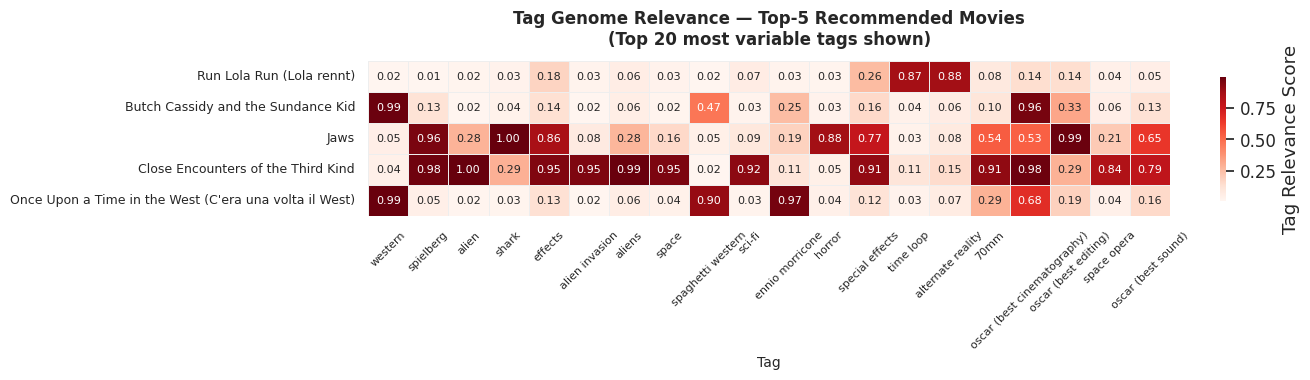

Heatmap saved to tag_heatmap.png


In [19]:
# tag Relevance Heatmap for Top-5 Movies
# Shows which content features (tags) are most strongly associated with each recommendation
# Makes the model's content-based reasoning interpretable

# Select the top 15 most discriminating tags for the recommended movies
top_movie_ids = recommendations['movieId'].tolist()
top_titles    = dict(zip(recommendations['movieId'],
                         recommendations['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)))

# Get genome vectors for just our top-5
heat_data = genome_matrix.loc[[mid for mid in top_movie_ids if mid in genome_matrix.index]]
heat_data.index = [top_titles[mid] for mid in heat_data.index]

# Pick the top 20 tags by variance across these 5 movies (most informative)
top_tags = heat_data.var(axis=0).nlargest(20).index
heat_data = heat_data[top_tags]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap='Reds',
    linewidths=0.4,
    linecolor='#EEEEEE',
    cbar_kws={'label': 'Tag Relevance Score', 'shrink': 0.8},
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8}
)

ax.set_title(
    'Tag Genome Relevance — Top-5 Recommended Movies\n(Top 20 most variable tags shown)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Tag', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('tag_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis Rationale

### Model Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Filtering method | Content-based via cosine similarity | Cold-start: no user history to enable collaborative filtering |
| Feature space | Tag genome (1,128 tags) | Precomputed, dense, and semantically rich — captures nuance beyond genre labels |
| User profile construction | Mean vector of top-50 popular genre-matched movies | Provides a stable, representative starting point; avoids overfitting to a single movie |
| Score weighting | 70% similarity, 30% popularity | Prioritizes content match but ensures recommendations are well-regarded by the community |
| Popularity normalization | Log-scaled rating count | Prevents blockbusters from dominating; rewards quality over volume |
| Rating threshold | Min 50 ratings | Eliminates movies too sparse to trust aggregate ratings |

### Limitations
- The tag genome covers only 13,000 of the 62,000 movies in the full dataset; movies without genome data are excluded from content-based ranking.
- The user profile is bootstrapped from popularity, not true user taste — this is appropriate for cold-start but should be updated quickly as watch history accumulates.
- Genre labels are coarse; a user who likes "Action" may prefer very different sub-genres (martial arts vs. superhero). The tag genome partially compensates for this.
